la structure de X est : 
   Unnamed: 0.1  Unnamed: 0   train gare        date  arret  p2q0  p3q0  p4q0  \
0             0           0  VBXNMF  KYF  2023-04-03      8   0.0   0.0   1.0   
1             1           1  VBXNMF  JLR  2023-04-03      9   0.0   0.0   0.0   
2             2           2  VBXNMF  EOH  2023-04-03     10  -1.0   0.0   0.0   
3             3           3  VBXNMF  VXY  2023-04-03     11  -1.0  -1.0   0.0   
4             4           4  VBXNMF  OCB  2023-04-03     12  -1.0  -1.0  -1.0   

   p0q2  p0q3  p0q4  
0  -3.0  -1.0  -2.0  
1   1.0   0.0   1.0  
2  -1.0   0.0   0.0  
3   2.0  -2.0   0.0  
4  -1.0   3.0   2.0  
la structure de y est :
    Unnamed: 0  p0q0
0           0  -1.0
1           1  -1.0
2           2  -1.0
3           3   1.0
4           4   3.0
la structure de x_rf est : 
                p2q0           p3q0           p4q0           p0q2  \
count  667264.000000  667264.000000  667264.000000  667264.000000   
mean       -0.170696      -0.167304      -0.1

<Figure size 1000x600 with 0 Axes>

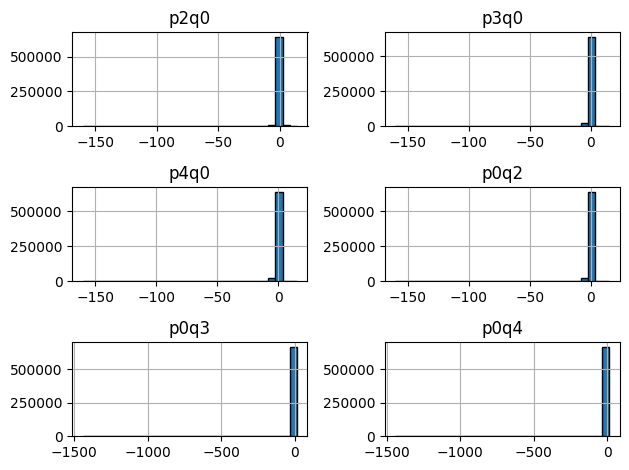

les valeurs maximales:424615    14.0
424616    14.0
218127    14.0
196804    13.0
227582    13.0
320668    13.0
218128    13.0
260589    12.0
546642    12.0
544331    12.0
Name: p2q0, dtype: float64
les valeurs maximales:546642    15.0
218128    14.0
424617    14.0
424616    14.0
320669    13.0
218129    13.0
196805    13.0
544332    12.0
123349    12.0
196806    12.0
Name: p3q0, dtype: float64
les valeurs maximales:544301    15.0
411690    15.0
546643    15.0
424617    14.0
218129    14.0
424618    14.0
196806    13.0
218130    13.0
196807    12.0
546644    12.0
Name: p4q0, dtype: float64
les valeurs maximales:411704    15.0
540429    15.0
219686    14.0
426500    14.0
423832    14.0
224786    13.0
217113    13.0
320258    13.0
257720    12.0
576504    12.0
Name: p0q2, dtype: float64
les valeurs maximales:541155    15.0
413818    15.0
426521    14.0
219265    14.0
426359    14.0
193558    13.0
220701    13.0
259756    12.0
578607    12.0
193108    12.0
Name: p0q3, dtype: float64
les v

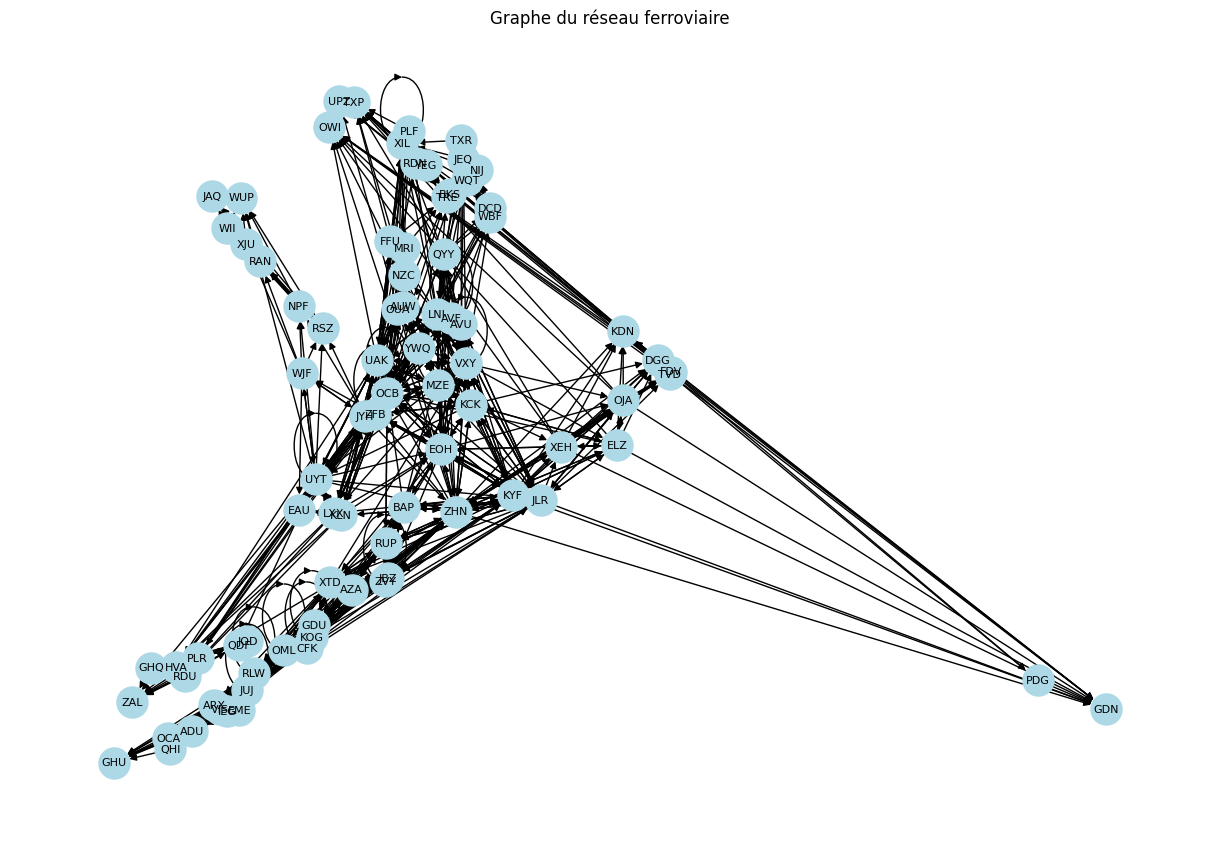

       p0q0
0 -1.011186
1 -0.229280
2 -0.229280
3 -0.343108
4 -0.214004
(20657, 1)
Passons au tensorflow
c:\Users\SARA\Desktop\machinelearning\venv\Scripts\python.exe
2.21.0
['p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4', 'arret', 'degree', 'gare_encoded']
p2q0            float64
p3q0            float64
p4q0            float64
p0q2            float64
p0q3            float64
p0q4            float64
arret             int64
degree            int64
gare_encoded    float64
dtype: object
Nombre de gares uniques : 84
Epoch 1/200
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.7200 - mae: 0.7200 - val_loss: 0.6974 - val_mae: 0.6974 - learning_rate: 0.0010
Epoch 2/200
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6882 - mae: 0.6882 - val_loss: 0.6837 - val_mae: 0.6837 - learning_rate: 0.0010
Epoch 3/200
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6790 - mae: 0.6790 - val_loss: 0.6796 - val_mae: 0.6796 - learning_rate: 0.0010
Epoch 4/200
1669/1669 ━━━━━━━━━━━━━━━━━━━━ 3s 2m

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import networkx as nx
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.layers import Dense, Embedding, Concatenate, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

X=pd.read_csv('x_train_final.csv')
y=pd.read_csv('y_train_final.csv')
print(f"la structure de X est : \n{X.head()}")
print(f"la structure de y est :\n {y.head()}")
x_rf=X[['p2q0','p3q0','p4q0','p0q2','p0q3','p0q4']]
y_rf=y['p0q0']
print(f"la structure de x_rf est : \n{x_rf.describe()}")
plt.figure(figsize=(10,6))
x_rf.hist(bins=30, edgecolor='black')
plt.tight_layout()
plt.show()
for a in x_rf:
    print(f"les valeurs maximales:{x_rf[a].sort_values(ascending=False).head(10)}")
for a in x_rf:
    print(f"les valeurs minimales:{x_rf[a].sort_values(ascending=True).head(10)}")
print(f"Optimiser les valeurs aberrantes de p0q4")
x_rf.loc[x_rf['p0q4'] < -160, 'p0q4'] = x_rf['p0q4'].median()
print(f"Optimiser les valeurs aberrantes de p0q3")
x_rf.loc[x_rf['p0q3'] < -160, 'p0q3'] = x_rf['p0q3'].median()
print(x_rf.describe())
print(X['date'].head())
print(X['date'].info())
X['date'] = pd.to_datetime(X['date'])
x_rf = x_rf.copy()
x_rf['day_of_week'] = X['date'].dt.dayofweek 
x_rf['month'] = X['date'].dt.month
print(f"Passons au colonnes categorielle de train et de test ")
print(f"les valeurs unique dans la colonne gare est : \n{X['gare'].nunique()}")
print(f"les valeurs uniques dans la colonne train sont : \n{X['train'].nunique()}")
x_rf['gare'] = X['gare'].values
print(x_rf.head())
print(x_rf.shape)

print(f"Essayons de voir l'importance des features")
print(f"Ajoutons la colonne arret")
x_rf['arret'] = X['arret'].values
print(f"les valeurs uniques dans la colonne arret sont : \n{x_rf['arret'].nunique()}")
print(f"les statistiques descriptives de la colonne arret sont : \n{x_rf['arret'].describe()}")

print(f"Passons a l'amelioration du modele en utilisant le graphe")
G = nx.DiGraph()
for (train, date), group in X.groupby(['train', 'date']):
    group = group.sort_values('arret')
    gares = group['gare'].values
    for i in range(len(gares) - 1):
        G.add_edge(gares[i], gares[i+1])
print(f"Nombre de noeuds : {G.number_of_nodes()}")
print(f"Nombre d'aretes : {G.number_of_edges()}")
degree_dict = dict(G.degree())
print(f"degre des noeuds : \n{degree_dict}")
x_rf['degree'] = X['gare'].map(degree_dict)
print(x_rf['degree'].describe())
x_rf = x_rf.drop(['day_of_week', 'month'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(x_rf, y_rf, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

gare_encoding = y_train.groupby(X_train['gare']).mean()
print(gare_encoding)
print(f"Passons à l'encodage de la colonne gare")
X_train['gare_encoded'] = X_train['gare'].map(gare_encoding)
X_test['gare_encoded'] = X_test['gare'].map(gare_encoding)
print(X_train[['gare', 'gare_encoded']].head(10))
print(X_test['gare_encoded'].isnull().sum())
print(f"Supprimons la colonne gare pour le RandomForest")

# On garde une copie de la colonne gare pour l'embedding avant de la supprimer
X_train_gare_col = X_train['gare'].copy()
X_test_gare_col  = X_test['gare'].copy()

X_train = X_train.drop('gare', axis=1)
X_test = X_test.drop('gare', axis=1)

rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=20, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(f"Apres prediction on a :")
print(f"MAE test : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"le score train : {rf.score(X_train, y_train):.4f}")
print(f"le score test  : {rf.score(X_test, y_test):.4f}")
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
print(f" les features les plus importantes : \n{importances.sort_values(ascending=False)}")
plt.figure(figsize=(12,8))
nx.draw(G, 
    with_labels=True,    
    node_size=500,       
    node_color='lightblue',  
    font_size=8,         
    arrows=True)         
plt.title('Graphe du réseau ferroviaire')
plt.show()

# Charger le vrai fichier de test du challenge
X_test_final = pd.read_csv('x_test_final.csv')

# Appliquer les mêmes transformations
x_test_final = X_test_final[['p2q0','p3q0','p4q0','p0q2','p0q3','p0q4']].copy()
x_test_final.loc[x_test_final['p0q4'] < -160, 'p0q4'] = x_rf['p0q4'].median()
x_test_final.loc[x_test_final['p0q3'] < -160, 'p0q3'] = x_rf['p0q3'].median()
x_test_final['arret'] = X_test_final['arret'].values
x_test_final['degree'] = X_test_final['gare'].map(degree_dict)
x_test_final['gare_encoded'] = X_test_final['gare'].map(gare_encoding)

# Prédire avec RandomForest
y_pred_final = rf.predict(x_test_final)

# Sauvegarder avec le bon index
submission = pd.DataFrame({'p0q0': y_pred_final}, index=X_test_final.index)
submission.to_csv('submission.csv', index=True)
print(submission.head())
print(submission.shape)

print(f"Passons au tensorflow")
import sys
print(sys.executable)
print(tf.__version__)
print(X_train.columns.tolist())
print(X_train.dtypes)



# Normalisation des features numériques
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Encodage des gares en entiers pour l'embedding
le = LabelEncoder()
X_train_gare = le.fit_transform(X_train_gare_col)
X_test_gare  = X_test_gare_col.map(
    dict(zip(le.classes_, le.transform(le.classes_)))
).fillna(0).astype(int).values

n_gares = len(le.classes_)
print(f"Nombre de gares uniques : {n_gares}")

# Classe mainModel selon le prof
# embedding de la gare + couches Dense + sortie
class mainModel(tf.keras.Model):
    def __init__(self, n_layers):
        super(mainModel, self).__init__()
        self.n_layers = n_layers
        # embedding : chaque gare représentée par 100 nombres appris automatiquement
        self.embedding = Embedding(
            input_dim=n_gares + 1,  # nombre de gares
            output_dim=100,          # chaque gare = 100 nombres
            trainable=True
        )
        # n_layers couches Dense de 64 neurones
        self.denses = [Dense(64, activation='relu') for i in range(n_layers)]
        self.output_layer = Dense(1)

    def call(self, X):
        X, id_gare = X
        # embedding de la gare
        X_gare = self.embedding(id_gare)
        X_gare = Flatten()(X_gare)
        # concatener features numériques + embedding gare
        X = Concatenate()([X, X_gare])
        # passer par les couches Dense
        for i in range(self.n_layers):
            X = self.denses[i](X)
        X = self.output_layer(X)
        return X

# Instancier le modèle avec 3 couches Dense
model = mainModel(n_layers=3)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mae',
    metrics=['mae']
)

# quand on a 5 epochs d'affilé qui ne varie pas ca s'arrete et on prend la meilleur loss
early_stop = EarlyStopping(
    monitor='val_mae',
    patience=5,
    restore_best_weights=True
)

# quand le modele stagne,reduction le learning rate automatiquement
reduce_lr = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=3,
    min_lr=0.00001
)

# deux entrées : features numériques + gare
history = model.fit(
    [X_train_scaled, X_train_gare],
    y_train,
    epochs=200,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_pred_nn = model.predict([X_test_scaled, X_test_gare])
mae_nn = mean_absolute_error(y_test, y_pred_nn)
print(f"MAE test réseau de neurones : {mae_nn:.4f}")
print(f"MAE test RandomForest       : {mean_absolute_error(y_test, y_pred):.4f}")

# Appliquer les transformations sur le test final pour le réseau de neurones
x_test_final_scaled = scaler.transform(x_test_final)

# Encoder les gares du test final avec le même LabelEncoder
x_test_final_gare = X_test_final['gare'].map(
    dict(zip(le.classes_, le.transform(le.classes_)))
).fillna(0).astype(int).values

# Prédire avec le réseau de neurones — deux entrées
y_pred_nn_final = model.predict([x_test_final_scaled, x_test_final_gare])

# Sauvegarder
submission_nn = pd.DataFrame({'p0q0': y_pred_nn_final.flatten()}, index=X_test_final.index)
submission_nn.to_csv('submission_nn.csv', index=True)
print(submission_nn.head())
print(submission_nn.shape)